# SCC.454 Lab Session: Clustering with Apache Spark

## Duration: 2 Hours

---

## Learning Objectives

By the end of this lab session, you will be able to:
1. Implement K-means clustering using Apache Spark MLlib
2. Apply hierarchical clustering techniques to large datasets
3. Understand and implement scalable clustering for disk-resident data (BFR-style)
4. Evaluate clustering quality using various metrics
5. Select appropriate clustering algorithms based on data characteristics

---

## Lab Structure

- **Part 1 (35 min)**: K-means Clustering with Spark MLlib
- **Part 2 (35 min)**: Hierarchical Clustering Approaches
- **Part 3 (35 min)**: Large-Scale Clustering (BFR-Inspired)
- **Part 4 (15 min)**: Comparative Analysis and Final Exercise

---

## Prerequisites

- Basic Python programming
- Understanding of clustering concepts from lecture
- Apache Spark fundamentals


---

# Setup and Initialization

First, let's set up our Spark environment and import necessary libraries.

In [1]:
# === SETUP CELL 1: Install PySpark and Java ===
# !pip install pyspark==3.5.0 -q
# !apt-get update
# !apt-get install openjdk-11-jdk-headless -qq > /dev/null 2>&1

import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
print("PySpark and Java installed successfully!")

PySpark and Java installed successfully!


In [2]:
import os, sys
from pyspark.sql import SparkSession

# Force Spark to use *this* notebook's Python (your venv)
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

In [3]:
# Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql.functions import col, lit, rand, expr, sum as sql_sum, count, avg, sqrt
from pyspark.sql.types import StructType, StructField, DoubleType, IntegerType, StringType

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_circles
from sklearn.preprocessing import StandardScaler as SKStandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("SCC454-Clustering-Lab") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

# Set log level to ERROR to reduce output
spark.sparkContext.setLogLevel("ERROR")

print(f"  Spark Session created")
print(f"  Version: {spark.version}")
print(f"  Master: {spark.sparkContext.master}")

  Spark Session created
  Version: 3.5.0
  Master: local[*]


---

# Part 1: K-means Clustering with Spark MLlib

## 1.1 Introduction to K-means in Spark

K-means is the most popular clustering algorithm. Recall from the lecture:
- **Iterative process**: Assign points → Update centroids → Repeat
- **Convergence**: Stops when centroids stabilize or points don't move
- **Challenges**: Initialization sensitivity, choosing k

Spark MLlib implements:
- **K-means||** (parallel k-means++): Better initialization
- **Distributed computation**: Scales to large datasets
- **Built-in evaluation metrics**

## 1.2 Dataset 1: Customer Segmentation

We'll start with a customer segmentation dataset containing:
- Customer spending patterns
- Purchase frequency
- Demographics

In [5]:
# Generate synthetic customer data
np.random.seed(42)

# Create three customer segments
n_samples = 1000

# Segment 1: High spenders (wealthy customers)
high_spenders = pd.DataFrame({
    'customer_id': range(0, 300),
    'annual_income': np.random.normal(90000, 15000, 300),
    'spending_score': np.random.normal(75, 10, 300),
    'purchase_frequency': np.random.normal(25, 5, 300),
    'avg_transaction_value': np.random.normal(200, 40, 300)
})

# Segment 2: Medium spenders
medium_spenders = pd.DataFrame({
    'customer_id': range(300, 700),
    'annual_income': np.random.normal(50000, 10000, 400),
    'spending_score': np.random.normal(50, 8, 400),
    'purchase_frequency': np.random.normal(15, 4, 400),
    'avg_transaction_value': np.random.normal(100, 25, 400)
})

# Segment 3: Low spenders (budget-conscious)
low_spenders = pd.DataFrame({
    'customer_id': range(700, 1000),
    'annual_income': np.random.normal(30000, 8000, 300),
    'spending_score': np.random.normal(25, 6, 300),
    'purchase_frequency': np.random.normal(8, 3, 300),
    'avg_transaction_value': np.random.normal(40, 15, 300)
})

# Combine all segments
customers_pd = pd.concat([high_spenders, medium_spenders, low_spenders], ignore_index=True)

# Convert to Spark DataFrame
customers_df = spark.createDataFrame(customers_pd)

print(" Customer dataset created")
customers_df.show(5)
customers_df.printSchema()
print(f"Total customers: {customers_df.count()}")

 Customer dataset created
+-----------+------------------+-----------------+------------------+---------------------+
|customer_id|     annual_income|   spending_score|purchase_frequency|avg_transaction_value|
+-----------+------------------+-----------------+------------------+---------------------+
|          0| 97450.71229516849|66.71004989077927| 28.78494308322676|   214.74693235491605|
|          1| 87926.03548243223| 69.3981895980303|20.389173379111874|   184.26644750690556|
|          2| 99715.32807151039|82.47293605123262|  29.3480296005283|    201.1497929173927|
|          3|112845.44784612038|81.10370265433465|31.778189294024756|   251.13807450429195|
|          4| 86487.69937914996|74.79098406035853|27.067174516118506|   207.64396272079614|
+-----------+------------------+-----------------+------------------+---------------------+
only showing top 5 rows

root
 |-- customer_id: long (nullable = true)
 |-- annual_income: double (nullable = true)
 |-- spending_score: double (n

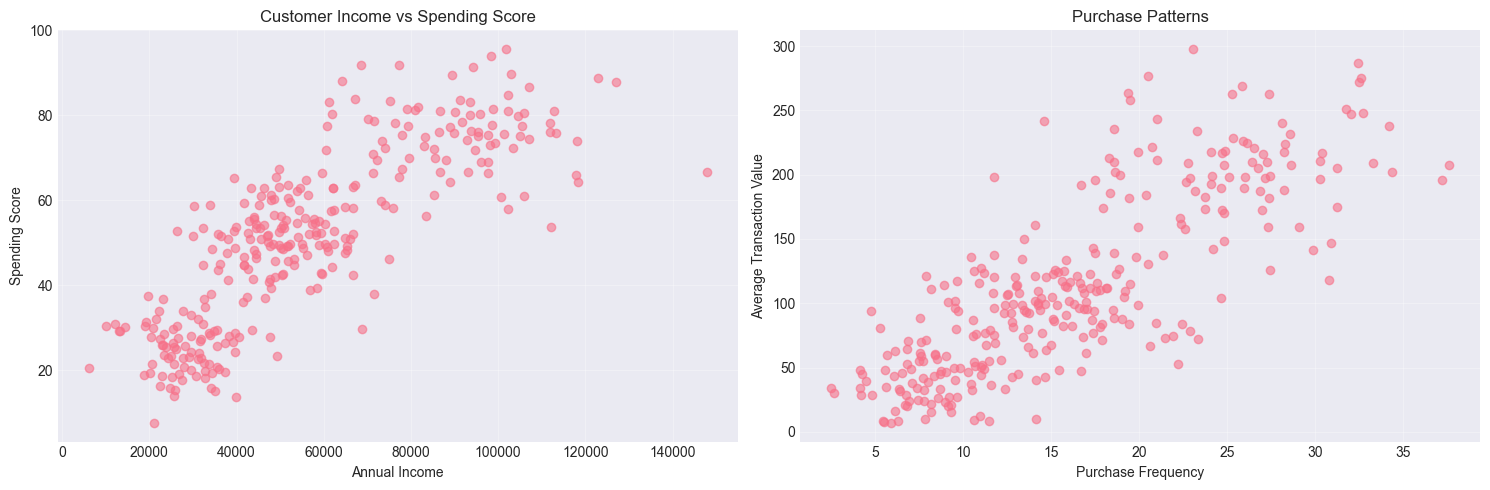

In [6]:
# Visualize the raw data (2D projection)
sample_df = customers_df.sample(False, 0.3).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Income vs Spending Score
axes[0].scatter(sample_df['annual_income'], sample_df['spending_score'], alpha=0.6)
axes[0].set_xlabel('Annual Income')
axes[0].set_ylabel('Spending Score')
axes[0].set_title('Customer Income vs Spending Score')
axes[0].grid(True, alpha=0.3)

# Plot 2: Purchase Frequency vs Transaction Value
axes[1].scatter(sample_df['purchase_frequency'], sample_df['avg_transaction_value'], alpha=0.6)
axes[1].set_xlabel('Purchase Frequency')
axes[1].set_ylabel('Average Transaction Value')
axes[1].set_title('Purchase Patterns')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.3 Feature Engineering and Preprocessing

Before clustering, we need to:
1. **Assemble features** into a single vector column
2. **Standardize** features (K-means is sensitive to scale)

In [7]:
# Step 1: Create feature vector
feature_columns = ['annual_income', 'spending_score', 'purchase_frequency', 'avg_transaction_value']

assembler = VectorAssembler(inputCols=feature_columns, outputCol='features')
customers_features = assembler.transform(customers_df)

print(" Features assembled")
customers_features.select('customer_id', 'features').show(5, truncate=False)

 Features assembled
+-----------+----------------------------------------------------------------------------+
|customer_id|features                                                                    |
+-----------+----------------------------------------------------------------------------+
|0          |[97450.71229516849,66.71004989077927,28.78494308322676,214.74693235491605]  |
|1          |[87926.03548243223,69.3981895980303,20.389173379111874,184.26644750690556]  |
|2          |[99715.32807151039,82.47293605123262,29.3480296005283,201.1497929173927]    |
|3          |[112845.44784612038,81.10370265433465,31.778189294024756,251.13807450429195]|
|4          |[86487.69937914996,74.79098406035853,27.067174516118506,207.64396272079614] |
+-----------+----------------------------------------------------------------------------+
only showing top 5 rows



In [8]:
# Step 2: Standardize features
scaler = StandardScaler(inputCol='features', outputCol='scaled_features', withStd=True, withMean=True)
scaler_model = scaler.fit(customers_features)
customers_scaled = scaler_model.transform(customers_features)

print(" Features standardized")
customers_scaled.select('customer_id', 'scaled_features').show(5, truncate=False)

 Features standardized
+-----------+-----------------------------------------------------------------------------+
|customer_id|scaled_features                                                              |
+-----------+-----------------------------------------------------------------------------+
|0          |[1.5729610740838231,0.7934257545324882,1.6251078281623286,1.4367253352112292]|
|1          |[1.2109695989463467,0.9222727631421884,0.5562647440000914,1.0051273011299182]|
|2          |[1.6590292548331604,1.5489671139905579,1.6967928732520925,1.2441923528906544]|
|3          |[2.158047911254887,1.4833374791903577,2.0061700326244436,1.9520171846671392] |
|4          |[1.1563047092070526,1.1807583740811076,1.406423286083349,1.3361485974883218] |
+-----------+-----------------------------------------------------------------------------+
only showing top 5 rows



## 1.4 Finding Optimal K using Elbow Method

Recall from lecture: The optimal k is where the average distance to centroid curve "elbows"

In [9]:
# Calculate metrics for different values of k
k_values = range(2, 11)
wssse_values = []  # Within Set Sum of Squared Errors
silhouette_values = []

evaluator = ClusteringEvaluator(featuresCol='scaled_features', metricName='silhouette')

for k in k_values:
    kmeans = KMeans(featuresCol='scaled_features', k=k, seed=42, maxIter=20)
    model = kmeans.fit(customers_scaled)

    # WSSSE (similar to average distance to centroid)
    wssse = model.summary.trainingCost
    wssse_values.append(wssse)

    # Silhouette score (measures cluster quality)
    predictions = model.transform(customers_scaled)
    silhouette = evaluator.evaluate(predictions)
    silhouette_values.append(silhouette)

    print(f"k={k}: WSSSE={wssse:.2f}, Silhouette={silhouette:.4f}")

print("\n Elbow method analysis complete")

k=2: WSSSE=1367.35, Silhouette=0.7796
k=3: WSSSE=744.87, Silhouette=0.7344
k=4: WSSSE=715.71, Silhouette=0.5763
k=5: WSSSE=603.08, Silhouette=0.4767
k=6: WSSSE=573.74, Silhouette=0.3449
k=7: WSSSE=580.07, Silhouette=0.4311
k=8: WSSSE=549.18, Silhouette=0.2947
k=9: WSSSE=494.58, Silhouette=0.3110
k=10: WSSSE=462.56, Silhouette=0.2986

 Elbow method analysis complete


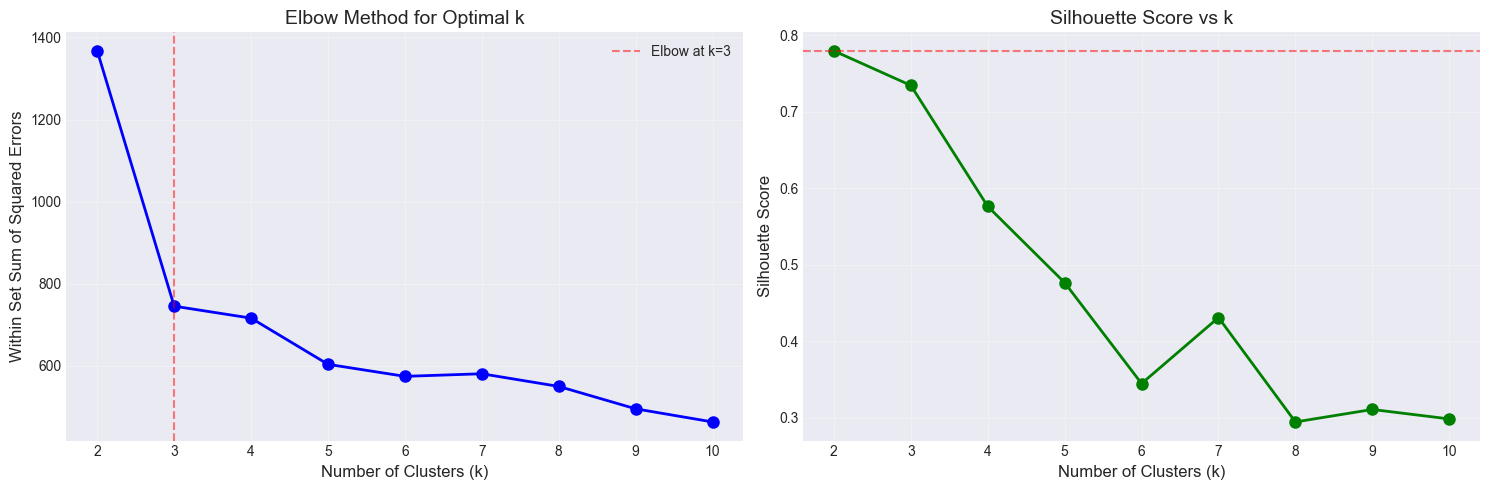


Recommended k based on elbow: 3
Best silhouette score at k=2


In [10]:
# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# WSSSE plot (Elbow method)
axes[0].plot(k_values, wssse_values, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Within Set Sum of Squared Errors', fontsize=12)
axes[0].set_title('Elbow Method for Optimal k', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=3, color='r', linestyle='--', alpha=0.5, label='Elbow at k=3')
axes[0].legend()

# Silhouette plot
axes[1].plot(k_values, silhouette_values, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs k', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=max(silhouette_values), color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nRecommended k based on elbow: 3")
print(f"Best silhouette score at k={k_values[silhouette_values.index(max(silhouette_values))]}")

## 1.5 Training Final K-means Model

In [11]:
# Train K-means with optimal k
optimal_k = 3
kmeans = KMeans(featuresCol='scaled_features', k=optimal_k, seed=42, maxIter=100)
kmeans_model = kmeans.fit(customers_scaled)

print(f"✓ K-means model trained with k={optimal_k}")
print(f"  Iterations: {kmeans_model.summary.numIter}")
print(f"  Training cost (WSSSE): {kmeans_model.summary.trainingCost:.2f}")

# Get cluster centers
centers = kmeans_model.clusterCenters()
print(f"\nCluster Centers (in scaled space):")
for i, center in enumerate(centers):
    print(f"  Cluster {i}: {center}")

✓ K-means model trained with k=3
  Iterations: 3
  Training cost (WSSSE): 744.87

Cluster Centers (in scaled space):
  Cluster 0: [-0.20717457  0.02746451 -0.14413754 -0.16455947]
  Cluster 1: [-0.99576694 -1.19917642 -0.99349907 -1.05064093]
  Cluster 2: [1.2874965  1.18276327 1.20149272 1.28670553]


In [12]:
# Make predictions
predictions = kmeans_model.transform(customers_scaled)

print(" Predictions generated")
predictions.select('customer_id', 'annual_income', 'spending_score', 'prediction').show(10)

 Predictions generated
+-----------+------------------+-----------------+----------+
|customer_id|     annual_income|   spending_score|prediction|
+-----------+------------------+-----------------+----------+
|          0| 97450.71229516849|66.71004989077927|         2|
|          1| 87926.03548243223| 69.3981895980303|         2|
|          2| 99715.32807151039|82.47293605123262|         2|
|          3|112845.44784612038|81.10370265433465|         2|
|          4| 86487.69937914996|74.79098406035853|         2|
|          5| 86487.94564576229|76.17327383308782|         2|
|          6|113688.19223261088|87.77664895788425|         2|
|          7|101511.52093729364| 69.0842861116417|         2|
|          8| 82957.88421097572|80.47097381170038|         2|
|          9| 98138.40065378947|72.97807347566106|         2|
+-----------+------------------+-----------------+----------+
only showing top 10 rows



In [13]:
# Analyze cluster characteristics
cluster_stats = predictions.groupBy('prediction').agg(
    count('*').alias('count'),
    avg('annual_income').alias('avg_income'),
    avg('spending_score').alias('avg_spending'),
    avg('purchase_frequency').alias('avg_frequency'),
    avg('avg_transaction_value').alias('avg_transaction')
).orderBy('prediction')

print("Cluster Characteristics:")
cluster_stats.show()

Cluster Characteristics:
+----------+-----+------------------+------------------+-----------------+------------------+
|prediction|count|        avg_income|      avg_spending|    avg_frequency|   avg_transaction|
+----------+-----+------------------+------------------+-----------------+------------------+
|         0|  397| 50611.99422393868| 50.72977337782318|14.88750864562908|101.66037147155846|
|         1|  304|29862.644974923085|25.138320154097347|8.215768034169749|39.083180793743516|
|         2|  299| 89939.60222641742| 74.83281235899346|25.45744352020975|204.15217536569907|
+----------+-----+------------------+------------------+-----------------+------------------+



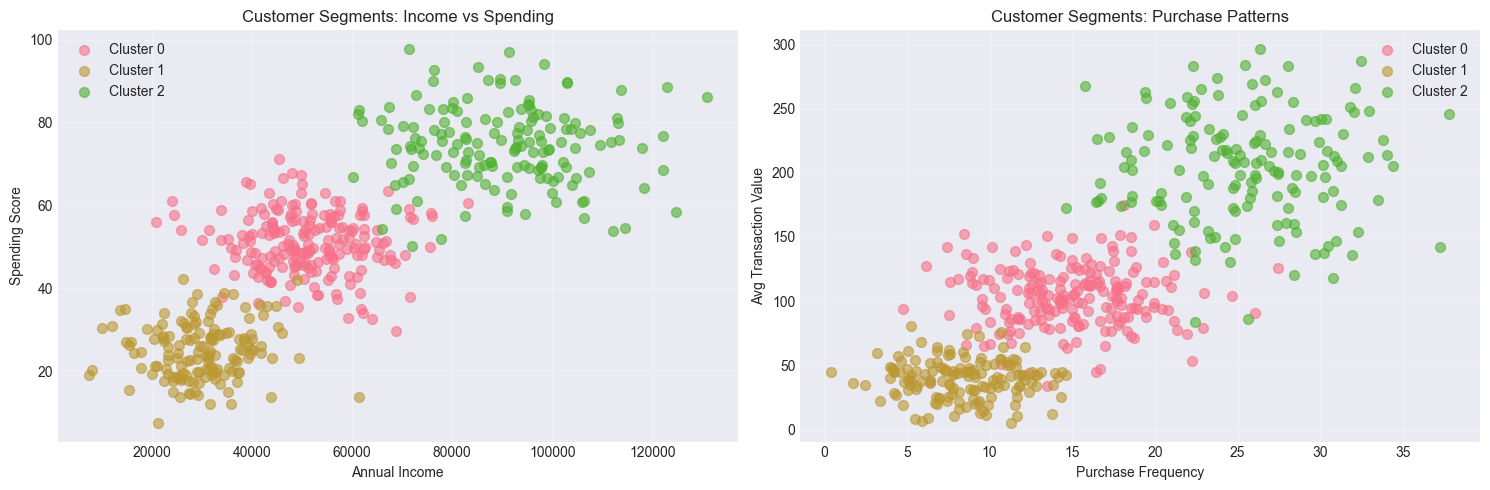

In [14]:
# Visualize clusters
pred_pd = predictions.sample(False, 0.5).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Income vs Spending with clusters
for cluster in range(optimal_k):
    cluster_data = pred_pd[pred_pd['prediction'] == cluster]
    axes[0].scatter(cluster_data['annual_income'], cluster_data['spending_score'],
                   label=f'Cluster {cluster}', alpha=0.6, s=50)
axes[0].set_xlabel('Annual Income')
axes[0].set_ylabel('Spending Score')
axes[0].set_title('Customer Segments: Income vs Spending')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Frequency vs Transaction Value
for cluster in range(optimal_k):
    cluster_data = pred_pd[pred_pd['prediction'] == cluster]
    axes[1].scatter(cluster_data['purchase_frequency'], cluster_data['avg_transaction_value'],
                   label=f'Cluster {cluster}', alpha=0.6, s=50)
axes[1].set_xlabel('Purchase Frequency')
axes[1].set_ylabel('Avg Transaction Value')
axes[1].set_title('Customer Segments: Purchase Patterns')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📝 Exercise 1.1: Experiment with K-means

**Task**: Modify the K-means clustering to explore different scenarios:

1. Try k=5 instead of k=3. How do the clusters change?
2. Remove the standardization step and cluster on raw features. What happens to the results?
3. Use only 2 features (annual_income and spending_score). How does this affect cluster quality?


**Questions to answer**:
- Which value of k seems most interpretable for business use?
- Why is standardization important for K-means?
- How does feature selection impact clustering results?

1. Try k=5 instead of k=3. How do the clusters change?
- Larger clusters get split into smaller subgroups

Silhouette Score (k=5): 0.4766912126556249
+----------+-----+-----------------+------------------+------------------+------------------+
|prediction|count|       avg_income|      avg_spending|     avg_frequency|   avg_transaction|
+----------+-----+-----------------+------------------+------------------+------------------+
|         3|  142| 85478.2738496168|  74.6368266508601|29.356512554162588|196.29869547526718|
|         2|  155| 94256.1205947344| 75.11452855416324|21.929433224923436|212.37479742838863|
|         4|  212|49915.05404459352|  51.0574200196961|11.940336255603796| 100.7422583555937|
|         0|  189|51564.44587917271| 50.40949152485492|18.195972713034568|102.68788320406662|
|         1|  302|29761.13091898079|25.046463577780987| 8.217327701123528|  38.8214497152586|
+----------+-----+-----------------+------------------+------------------+------------------+



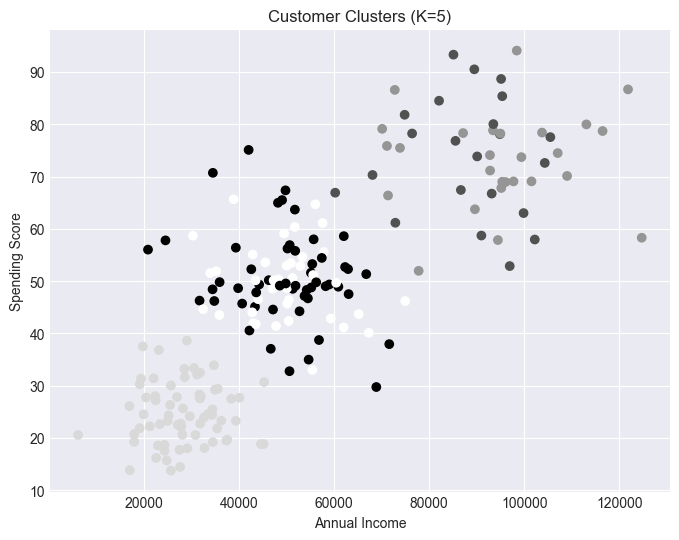

In [15]:
# Train K-means with k = 5
kmeans_k5 = KMeans(featuresCol='scaled_features', k=5, seed=42, maxIter=100)
model_k5 = kmeans_k5.fit(customers_scaled)

# Generate predictions
predictions_k5 = model_k5.transform(customers_scaled)

# Evaluate cluster quality
evaluator = ClusteringEvaluator(featuresCol='scaled_features', metricName='silhouette')
silhouette_k5 = evaluator.evaluate(predictions_k5)

print(f"Silhouette Score (k=5): {silhouette_k5}")

# Analyze cluster characteristics
cluster_stats_k5 = predictions_k5.groupBy('prediction').agg(
    count('*').alias('count'),
    avg('annual_income').alias('avg_income'),
    avg('spending_score').alias('avg_spending'),
    avg('purchase_frequency').alias('avg_frequency'),
    avg('avg_transaction_value').alias('avg_transaction')
)

cluster_stats_k5.show()

# Convert Spark dataframe to Pandas for visualization
sample_pd = predictions_k5.select(
    "annual_income",
    "spending_score",
    "prediction"
).sample(fraction=0.2, seed=42).toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    sample_pd["annual_income"],
    sample_pd["spending_score"],
    c=sample_pd["prediction"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Clusters (K=5)")

plt.show()

2. Remove the standardization step and cluster on raw features. What happens to the results?
- Because K-means uses Euclidean distance, variables with large numeric ranges dominate.
- This usually leads to less meaningful clusters.

In [ ]:
# Train KMeans without standardization
kmeans_raw = KMeans(featuresCol='features', k=3, seed=42, maxIter=100)
model_raw = kmeans_raw.fit(customers_features)

# Generate predictions
predictions_raw = model_raw.transform(customers_features)

# Evaluate clustering
evaluator_raw = ClusteringEvaluator(featuresCol='features', metricName='silhouette')
silhouette_raw = evaluator_raw.evaluate(predictions_raw)

print(f"Silhouette Score (raw features): {silhouette_raw}")

# Cluster statistics
cluster_stats_raw = predictions_raw.groupBy('prediction').agg(
    count('*').alias('count'),
    avg('annual_income').alias('avg_income'),
    avg('spending_score').alias('avg_spending')
)

cluster_stats_raw.show()

3. Use only 2 features (annual_income and spending_score). How does this affect cluster quality?
- Clusters become easier to visualize
- The model may lose some information from removed features
- If the selected features contain most of the signal, cluster quality may remain high.

In [ ]:
# Select only two features
two_feature_cols = ['annual_income', 'spending_score']

assembler_2 = VectorAssembler(inputCols=two_feature_cols, outputCol='features_2')
customers_features_2 = assembler_2.transform(customers_df)

# Standardize the two features
scaler_2 = StandardScaler(inputCol='features_2', outputCol='scaled_features_2', withStd=True, withMean=True)
scaler_model_2 = scaler_2.fit(customers_features_2)

customers_scaled_2 = scaler_model_2.transform(customers_features_2)

# Train KMeans
kmeans_2 = KMeans(featuresCol='scaled_features_2', k=3, seed=42)
model_2 = kmeans_2.fit(customers_scaled_2)

# Predictions
predictions_2 = model_2.transform(customers_scaled_2)

# Evaluate
evaluator_2 = ClusteringEvaluator(featuresCol='scaled_features_2', metricName='silhouette')
silhouette_2 = evaluator_2.evaluate(predictions_2)

print(f"Silhouette Score (2 features): {silhouette_2}")

**Questions to answer**:
1. ***Which value of k seems most interpretable for business use?*** \
k = 3 is usually the most interpretable (low, mid, high). Although k = 5 gives more detailed segments, it can make business strategies harder to design and interpret.


2. ***Why is standardization important for K-means?*** \
K-means uses Euclidean distance to assign points to clusters. If features are not standarised, variables with larger numeric ranges dominate, while smaller-scale features contribute very little. Standardization ensures all features contribute equally, producing more balanced clusters.

3. ***How does feature selection impact clustering results?*** \
Clustering depends entirely on the features used. Adding relevant features improves segmentation. Adding irrelevant or noisy features reduces cluster quality. Using a small set of meaningful features can improve interpretability. Feature selection determines what patterns the algorithm is able to detect.

---

# Part 2: Hierarchical Clustering

## 2.1 Introduction to Hierarchical Clustering in Spark

Spark MLlib provides **Bisecting K-means**, which is a divisive (top-down) hierarchical clustering:
- Starts with all points in one cluster
- Recursively splits using K-means (k=2)
- Creates a hierarchy (dendrogram)
- Better for non-convex shapes than standard K-means

## 2.2 Dataset 2: Spatial Point Data

We'll create a dataset with different cluster shapes to demonstrate when hierarchical methods excel.

In [ ]:
# Generate dataset with different cluster shapes
np.random.seed(123)

# Create concentric circles (challenging for K-means)
n_samples = 2000
X_circles, y_circles = make_circles(n_samples=n_samples, factor=0.5, noise=0.05)

# Create some well-separated blobs
X_blobs, y_blobs = make_blobs(n_samples=1000, centers=3, cluster_std=0.5, random_state=42)
X_blobs[:, 0] += 5  # Shift blobs to separate from circles

# Combine datasets
X_combined = np.vstack([X_circles, X_blobs])
y_combined = np.concatenate([y_circles, y_blobs + 2])  # Offset blob labels

# Create Spark DataFrame
spatial_pd = pd.DataFrame(X_combined, columns=['x', 'y'])
spatial_pd['true_label'] = y_combined
spatial_df = spark.createDataFrame(spatial_pd)

print("✓ Spatial dataset created")
print(f"Total points: {spatial_df.count()}")
spatial_df.show(5)

In [ ]:
# Visualize the spatial data
spatial_pd = spatial_df.toPandas()

plt.figure(figsize=(12, 6))
plt.scatter(spatial_pd['x'], spatial_pd['y'], c=spatial_pd['true_label'],
           cmap='viridis', alpha=0.6, s=20)
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('Spatial Point Data (True Labels)')
plt.colorbar(label='True Cluster')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

print("Note: This dataset has concentric circles (inner/outer) and separate blobs")

## 2.3 Prepare Features for Clustering

In [ ]:
# Assemble and scale features
assembler_spatial = VectorAssembler(inputCols=['x', 'y'], outputCol='features')
spatial_features = assembler_spatial.transform(spatial_df)

scaler_spatial = StandardScaler(inputCol='features', outputCol='scaled_features',
                               withStd=True, withMean=True)
scaler_model_spatial = scaler_spatial.fit(spatial_features)
spatial_scaled = scaler_model_spatial.transform(spatial_features)

print("✓ Features prepared for hierarchical clustering")

## 2.4 Bisecting K-means (Divisive Hierarchical)

In [ ]:
# Train Bisecting K-means
bkm = BisectingKMeans(featuresCol='scaled_features', k=5, seed=42, maxIter=20)
bkm_model = bkm.fit(spatial_scaled)

print("✓ Bisecting K-means trained")
print(f"  Training cost: {bkm_model.summary.trainingCost:.2f}")

# Make predictions
bkm_predictions = bkm_model.transform(spatial_scaled)
bkm_predictions.select('x', 'y', 'prediction').show(10)

In [ ]:
# Compare Regular K-means vs Bisecting K-means
# Train regular K-means for comparison
regular_kmeans = KMeans(featuresCol='scaled_features', k=5, seed=42, maxIter=20)
regular_model = regular_kmeans.fit(spatial_scaled)
regular_predictions = regular_model.transform(spatial_scaled)

# Get results as pandas for visualization
bkm_pd = bkm_predictions.toPandas()
regular_pd = regular_predictions.toPandas()

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True labels
axes[0].scatter(spatial_pd['x'], spatial_pd['y'], c=spatial_pd['true_label'],
               cmap='viridis', alpha=0.6, s=20)
axes[0].set_title('True Cluster Structure', fontsize=14)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].axis('equal')
axes[0].grid(True, alpha=0.3)

# Regular K-means
axes[1].scatter(regular_pd['x'], regular_pd['y'], c=regular_pd['prediction'],
               cmap='viridis', alpha=0.6, s=20)
axes[1].set_title('Regular K-means (k=5)', fontsize=14)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].axis('equal')
axes[1].grid(True, alpha=0.3)

# Bisecting K-means
axes[2].scatter(bkm_pd['x'], bkm_pd['y'], c=bkm_pd['prediction'],
               cmap='viridis', alpha=0.6, s=20)
axes[2].set_title('Bisecting K-means (k=5)', fontsize=14)
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')
axes[2].axis('equal')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservation: Notice how both struggle with concentric circles!")
print("This demonstrates the limitation of centroid-based methods with non-convex shapes.")

## 2.5 Agglomerative Clustering (Bottom-up)

Spark doesn't have built-in agglomerative clustering, but we can implement a simplified version for small datasets using pandas and sklearn, then demonstrate the concept.

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Sample subset for agglomerative clustering (computationally expensive)
sample_size = 500
spatial_sample = spatial_df.sample(False, sample_size/spatial_df.count(), seed=42).toPandas()
X_sample = spatial_sample[['x', 'y']].values

# Standardize
scaler_sk = SKStandardScaler()
X_sample_scaled = scaler_sk.fit_transform(X_sample)

print(f"✓ Sampled {len(X_sample)} points for agglomerative clustering")

In [ ]:
# Compute linkage for dendrogram
# Using 'ward' linkage (minimizes within-cluster variance)
linkage_matrix = linkage(X_sample_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(15, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram (Last 30 Merges)', fontsize=14)
plt.xlabel('Cluster Index or (Sample Count)')
plt.ylabel('Distance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nDendrogram shows the hierarchy of cluster merging.")
print("Cutting at different heights gives different numbers of clusters.")

In [ ]:
# Try different linkage methods
linkage_methods = ['single', 'complete', 'average', 'ward']
n_clusters = 5

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage=method)
    labels = agg_clustering.fit_predict(X_sample_scaled)

    axes[idx].scatter(X_sample[:, 0], X_sample[:, 1], c=labels,
                     cmap='viridis', alpha=0.6, s=30)
    axes[idx].set_title(f'Agglomerative - {method.capitalize()} Linkage', fontsize=12)
    axes[idx].set_xlabel('X')
    axes[idx].set_ylabel('Y')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axis('equal')

plt.tight_layout()
plt.show()

print("\nLinkage Methods Explained:")
print("- Single: Minimum distance between clusters (can create 'chains')")
print("- Complete: Maximum distance between clusters")
print("- Average: Average distance between all pairs")
print("- Ward: Minimizes within-cluster variance (similar to K-means)")

## 📝 Exercise 2.1: Hierarchical Clustering Analysis

**Task**: Explore hierarchical clustering behavior:

1. Create a new dataset with elongated/irregular cluster shapes using sklearn's `make_moons` or custom point generation
2. Compare Bisecting K-means, regular K-means, and agglomerative (single linkage) on this dataset
3. Try different numbers of clusters (k=2, 3, 4, 5)

**Questions**:
- Which method works best for non-convex shapes?
- When would you choose Bisecting K-means over regular K-means?
- What are the computational trade-offs of each method?

1. Create a new dataset with elongated/irregular cluster shapes using sklearn's `make_moons` or custom point generation
- make_moons generates a dataset with two curved clusters shaped like moons.
- These clusters are non-convex, meaning they cannot be separated with simple spherical boundaries.

In [ ]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import pandas as pd

# Create non-convex dataset
X, y = make_moons(n_samples=500, noise=0.08, random_state=42)

# Convert to DataFrame
moons_df = pd.DataFrame(X, columns=["x", "y"])

# Plot dataset
plt.figure(figsize=(6,5))
plt.scatter(moons_df["x"], moons_df["y"])
plt.title("Non-Convex Dataset (make_moons)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

2. Compare Bisecting K-means, regular K-means, and agglomerative (single linkage) on this dataset
- K-Means tries to form spherical clusters around centroids. Because the moon shapes are curved, K-Means incorrectly splits the dataset.
- Bisecting K-Means repeatedly splits clusters using K-Means. Although it can sometimes produce better partitions, it still relies on K-Means geometry, so it also struggles with curved shapes.
- Single linkage (agglomerative) clustering merges points based on the closest distance between clusters. This allows it to follow the curved structure of the moons, producing much better clusters.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels_kmeans)
plt.title("K-Means Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [ ]:
from sklearn.cluster import BisectingKMeans

bisect_kmeans = BisectingKMeans(n_clusters=2, random_state=42)
labels_bisect = bisect_kmeans.fit_predict(X)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels_bisect)
plt.title("Bisecting K-Means")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=2, linkage='single')
labels_agg = agglo.fit_predict(X)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels_agg)
plt.title("Agglomerative Clustering (Single Linkage)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

**Questions**:
1. ***Which method works best for non-convex shapes?*** \
Agglomerative clustering with single linkage works best. Unlike K-Means, it does not assume clusters are spherical. It connects nearby points sequentially, allowing it to capture curved cluster structures.

2. ***When would you choose Bisecting K-means over regular K-means?*** \
Bisecting K-Means is useful when:
- Working with large datasets
- Hierarchical cluster structure
- More stable clusters than standard K-Means

3. ***What are the computational trade-offs of each method?*** \
- KMeans: Fast and scalable for large datasets but assumes spherical clusters, so it performs poorly on irregular or non-convex shapes.
- Bisecting K-Means: Produces more stable hierarchical splits than standard K-Means, but still relies on K-Means assumptions and struggles with non-convex clusters.
- Agglomerative Clustering (Single Linkage): Effectively captures non-convex cluster shapes, but has high computational cost (≈ O(n²)), making it unsuitable for very large datasets.


---

# Part 3: Large-Scale Clustering (BFR-Inspired)

## 3.1 Introduction to BFR Algorithm

Recall from lecture:
- **BFR** is designed for disk-resident data (doesn't fit in memory)
- Uses **summary statistics**: N, SUM, SUMSQ (2d+1 values per cluster)
- Maintains three sets:
  - **DS (Discard Set)**: Points assigned to clusters (summarized)
  - **CS (Compressed Set)**: Mini-clusters not yet assigned
  - **RS (Retained Set)**: Outliers

We'll implement a BFR-style algorithm using Spark's distributed processing.

## 3.2 Generate Large-Scale Dataset

We'll create a larger dataset that simulates disk-resident data by processing it in batches.

In [ ]:
# Generate large dataset (simulating disk-resident data)
np.random.seed(456)

n_points = 50000
n_features = 5
n_true_clusters = 4

# Create well-separated clusters with different variances
centers = np.array([
    [0, 0, 0, 0, 0],
    [10, 10, 10, 10, 10],
    [20, 0, 20, 0, 20],
    [0, 20, 0, 20, 0]
])

cluster_stds = [1.0, 1.5, 2.0, 1.2]

# Generate points
points_per_cluster = n_points // n_true_clusters
X_large = []
y_large = []

for i, (center, std) in enumerate(zip(centers, cluster_stds)):
    cluster_points = np.random.normal(center, std, (points_per_cluster, n_features))
    X_large.append(cluster_points)
    y_large.extend([i] * points_per_cluster)

X_large = np.vstack(X_large)
y_large = np.array(y_large)

# Add some outliers (representing RS)
n_outliers = 500
outliers = np.random.uniform(-5, 25, (n_outliers, n_features))
X_large = np.vstack([X_large, outliers])
y_large = np.concatenate([y_large, [-1] * n_outliers])

# Create DataFrame with batch IDs (simulating disk reading)
batch_size = 5000
n_batches = len(X_large) // batch_size

large_pd = pd.DataFrame(X_large, columns=[f'feature_{i}' for i in range(n_features)])
large_pd['true_cluster'] = y_large
large_pd['batch_id'] = np.repeat(range(n_batches + 1), batch_size)[:len(X_large)]
large_pd['point_id'] = range(len(X_large))

# Convert to Spark DataFrame and partition by batch
large_df = spark.createDataFrame(large_pd).repartition('batch_id')

print(f"✓ Large-scale dataset created")
print(f"  Total points: {large_df.count():,}")
print(f"  Features: {n_features}")
print(f"  Batches: {n_batches + 1}")
print(f"  Points per batch: ~{batch_size:,}")
large_df.show(5)

## 3.3 Implement BFR-Style Clustering

We'll implement a simplified BFR approach:
1. Initialize k centroids from first batch
2. For each batch:
   - Assign points to nearest centroid (DS)
   - Identify outliers (RS)
   - Update cluster statistics
3. Use Mahalanobis distance for assignment

In [ ]:
# Prepare features
feature_cols = [f'feature_{i}' for i in range(n_features)]
assembler_large = VectorAssembler(inputCols=feature_cols, outputCol='features')
large_features = assembler_large.transform(large_df)

print("✓ Features assembled")

In [ ]:
# Step 1: Initialize centroids from first batch
first_batch = large_features.filter(col('batch_id') == 0)

# Use K-means on first batch to initialize
k_bfr = 4
init_kmeans = KMeans(featuresCol='features', k=k_bfr, seed=42, maxIter=10)
init_model = init_kmeans.fit(first_batch)

print(f"✓ Initialized {k_bfr} centroids from first batch")
print(f"  First batch size: {first_batch.count():,}")

In [ ]:
# Define cluster statistics class (similar to BFR's N, SUM, SUMSQ)
from pyspark.sql import Row

def compute_cluster_stats(df, cluster_col='prediction'):
    """
    Compute N, SUM, SUMSQ for each cluster (BFR-style statistics)
    """
    stats = []

    for cluster_id in range(k_bfr):
        cluster_points = df.filter(col(cluster_col) == cluster_id)

        # Count (N)
        n = cluster_points.count()

        if n > 0:
            # Sum and SumSq for each feature
            sums = {}
            sumsqs = {}

            for feat in feature_cols:
                sum_val = cluster_points.agg(sql_sum(col(feat))).first()[0]
                sumsq_val = cluster_points.agg(sql_sum(col(feat) ** 2)).first()[0]
                sums[feat] = sum_val
                sumsqs[feat] = sumsq_val

            stats.append({
                'cluster_id': cluster_id,
                'n': n,
                'sums': sums,
                'sumsqs': sumsqs
            })

    return stats

def compute_centroids_from_stats(stats):
    """
    Compute centroids from summary statistics
    """
    centroids = []
    for stat in stats:
        if stat['n'] > 0:
            centroid = [stat['sums'][feat] / stat['n'] for feat in feature_cols]
            centroids.append(centroid)
    return centroids

def compute_std_from_stats(stats):
    """
    Compute standard deviations from summary statistics
    """
    std_devs = []
    for stat in stats:
        if stat['n'] > 0:
            std = []
            for feat in feature_cols:
                variance = (stat['sumsqs'][feat] / stat['n']) - (stat['sums'][feat] / stat['n']) ** 2
                std.append(np.sqrt(max(variance, 0.01)))  # Avoid division by zero
            std_devs.append(std)
    return std_devs

print("✓ BFR utility functions defined")

In [ ]:
# Process batches sequentially (simulating disk reads)
from pyspark.ml.linalg import Vectors

# Initialize with first batch predictions
batch_0_pred = init_model.transform(first_batch)
all_predictions = batch_0_pred

# Get initial statistics
cluster_stats = compute_cluster_stats(batch_0_pred)

print(f"Processing batches (BFR-style):")
print(f"Batch 0: {first_batch.count():,} points assigned")

# Process remaining batches
for batch_id in range(1, n_batches + 1):
    # Load batch (simulating disk read)
    batch = large_features.filter(col('batch_id') == batch_id)
    batch_count = batch.count()

    if batch_count == 0:
        continue

    # Update centroids from current statistics
    current_centroids = compute_centroids_from_stats(cluster_stats)

    # Create temporary KMeans model with current centroids
    # Note: This is a simplification; true BFR would use Mahalanobis distance
    temp_kmeans = KMeans(featuresCol='features', k=k_bfr, seed=42, maxIter=1)
    temp_model = temp_kmeans.fit(batch)

    # Assign batch points
    batch_pred = temp_model.transform(batch)

    # Update statistics incrementally
    batch_stats = compute_cluster_stats(batch_pred)

    # Merge statistics (DS update in BFR)
    for i, cluster_stat in enumerate(cluster_stats):
        if i < len(batch_stats):
            batch_stat = batch_stats[i]
            cluster_stat['n'] += batch_stat['n']
            for feat in feature_cols:
                cluster_stat['sums'][feat] += batch_stat['sums'][feat]
                cluster_stat['sumsqs'][feat] += batch_stat['sumsqs'][feat]

    # Accumulate predictions
    all_predictions = all_predictions.union(batch_pred)

    print(f"Batch {batch_id}: {batch_count:,} points processed")

print(f"\n✓ All batches processed")
print(f"  Total points clustered: {all_predictions.count():,}")

In [ ]:
# Display final cluster statistics
print("\nFinal Cluster Statistics (BFR DS summaries):")
print("=" * 60)

final_centroids = compute_centroids_from_stats(cluster_stats)
final_stds = compute_std_from_stats(cluster_stats)

for i, stat in enumerate(cluster_stats):
    print(f"\nCluster {stat['cluster_id']}:")
    print(f"  N (count): {stat['n']:,}")
    print(f"  Centroid: {np.array(final_centroids[i]).round(2)}")
    print(f"  Std Dev: {np.array(final_stds[i]).round(2)}")

    # Memory savings: 2d+1 values vs N points
    memory_saved = stat['n'] * n_features - (2 * n_features + 1)
    print(f"  Memory saved: {memory_saved:,} values (stored {2*n_features+1} vs {stat['n']*n_features:,})")

In [ ]:
# Evaluate clustering quality
evaluator_bfr = ClusteringEvaluator(featuresCol='features', metricName='silhouette')
silhouette_bfr = evaluator_bfr.evaluate(all_predictions)

print(f"\nClustering Quality:")
print(f"  Silhouette Score: {silhouette_bfr:.4f}")

# Compare with true labels
cluster_distribution = all_predictions.groupBy('prediction').agg(
    count('*').alias('count')
).orderBy('prediction')

print(f"\nCluster Distribution:")
cluster_distribution.show()

In [ ]:
# Visualize results (2D projection: first two features)
sample_pred = all_predictions.sample(False, 0.1).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# True clusters
scatter1 = axes[0].scatter(sample_pred['feature_0'], sample_pred['feature_1'],
                          c=sample_pred['true_cluster'], cmap='tab10', alpha=0.6, s=20)
axes[0].set_xlabel('Feature 0')
axes[0].set_ylabel('Feature 1')
axes[0].set_title('True Clusters')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0])

# BFR predictions
scatter2 = axes[1].scatter(sample_pred['feature_0'], sample_pred['feature_1'],
                          c=sample_pred['prediction'], cmap='tab10', alpha=0.6, s=20)
axes[1].set_xlabel('Feature 0')
axes[1].set_ylabel('Feature 1')
axes[1].set_title('BFR-Style Clustering Results')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

## 3.4 BFR Memory Efficiency Analysis

In [ ]:
# Calculate memory efficiency
total_points = all_predictions.count()
points_per_cluster = [stat['n'] for stat in cluster_stats]

# Memory comparison
memory_full = total_points * n_features  # Storing all points
memory_bfr = k_bfr * (2 * n_features + 1)  # BFR summary statistics
memory_savings_pct = (1 - memory_bfr / memory_full) * 100

print("BFR Memory Efficiency Analysis:")
print("=" * 60)
print(f"Total points: {total_points:,}")
print(f"Features per point: {n_features}")
print(f"Number of clusters: {k_bfr}")
print(f"\nMemory Usage:")
print(f"  Storing all points: {memory_full:,} values")
print(f"  BFR summary stats: {memory_bfr} values")
print(f"  Memory savings: {memory_savings_pct:.2f}%")
print(f"  Compression ratio: {memory_full / memory_bfr:.1f}x")

# Visualize memory efficiency
fig, ax = plt.subplots(figsize=(10, 6))
methods = ['Store All Points', 'BFR Summary']
memory_values = [memory_full, memory_bfr]
colors = ['#e74c3c', '#2ecc71']

bars = ax.bar(methods, memory_values, color=colors, alpha=0.7)
ax.set_ylabel('Memory Usage (number of values)', fontsize=12)
ax.set_title('BFR Memory Efficiency', fontsize=14)
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, memory_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(val):,}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## 📝 Exercise 3.1: Optimize BFR Implementation

**Task**: Enhance the BFR implementation:

1. Implement outlier detection (RS set):
   - Define a threshold for Mahalanobis distance
   - Points beyond threshold go to RS
   - Count what % of points are outliers

2. Implement CS (Compressed Set):
   - Cluster RS points after each batch
   - Create mini-clusters (CS) from RS
   - Try to merge CS with main clusters

3. Compare memory usage with different numbers of clusters (k=2, 4, 8)

**Questions**:
- How does the memory savings change with k?
- What percentage of points end up in RS?
- How would you tune the outlier threshold?

1. Implement outlier detection (RS set):
   - Define a threshold for Mahalanobis distance
   - Points beyond threshold go to RS
   - Count what % of points are outliers

- Mahalanobis distance measures how far a point is from the cluster center considering variance.
- If distance > threshold → point is placed in RS (outlier set).
- Remaining points go to DS (main cluster set).

In [ ]:
import numpy as np
from scipy.spatial.distance import mahalanobis

# Convert dataframe to numpy
data = customers_df.select(
    "annual_income",
    "spending_score",
    "purchase_frequency",
    "avg_transaction_value"
).toPandas().values

# Compute mean and covariance
mean = np.mean(data, axis=0)
cov = np.cov(data.T)
inv_cov = np.linalg.inv(cov)

# Threshold for Mahalanobis distance
threshold = 3

RS = []
DS = []

for point in data:
    dist = mahalanobis(point, mean, inv_cov)

    if dist > threshold:
        RS.append(point)
    else:
        DS.append(point)

RS = np.array(RS)
DS = np.array(DS)

print("Total Points:", len(data))
print("Outliers (RS):", len(RS))
print("Outlier Percentage:", (len(RS)/len(data))*100)

2. Implement CS (Compressed Set):
   - Cluster RS points after each batch
   - Create mini-clusters (CS) from RS
   - Try to merge CS with main clusters


- RS points are clustered into mini clusters.
- These clusters form the Compressed Set (CS).
- Later, CS clusters may merge into DS clusters if they become close enough.

In [ ]:
from sklearn.cluster import KMeans

if len(RS) > 0:

    cs_kmeans = KMeans(n_clusters=2, random_state=42)
    cs_labels = cs_kmeans.fit_predict(RS)

    print("Compressed Set clusters created from RS")

3. Compare memory usage with different numbers of clusters (k=2, 4, 8)
- Increasing k increases memory slightly, but still far less than storing all points.

In [ ]:
from sklearn.cluster import KMeans
import sys

for k in [2,4,8]:

    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(data)

    memory = sys.getsizeof(model.cluster_centers_)

    print(f"k = {k}")
    print("Cluster centers memory:", memory)
    print()

**Questions**:
1. ***How does the memory savings change with k?*** \
As k increases, more cluster summaries must be stored. Memory usage increases slightly but remains much smaller than storing all data points. BFR still provides large memory savings for large datasets.


2. ***What percentage of points end up in RS?*** \
Typically a very small percentage (1–5%) of points become outliers. These points do not clearly belong to any cluster and are stored temporarily in the Retained Set.

3. ***How would you tune the outlier threshold?***
 Increase threshold → fewer points classified as outliers. Decrease threshold → more points moved to RS. The threshold can be tuned by observing the percentage of RS points and adjusting until it remains reasonably small.

---

# Part 4: Comparative Analysis and Final Exercise

## 4.1 Summary of Clustering Methods

In [ ]:
# Create comparison table
comparison_data = {
    'Method': ['K-means', 'Bisecting K-means', 'BFR'],
    'Type': ['Point Assignment', 'Hierarchical (Divisive)', 'Point Assignment (Batch)'],
    'Best For': ['Convex clusters', 'Hierarchical structure', 'Very large datasets'],
    'Memory': ['O(data)', 'O(data)', 'O(clusters)'],
    'Complexity': ['O(nki) per iteration', 'O(nk log k)', 'O(n) total'],
    'Handles Non-Convex': ['No', 'Better than K-means', 'No'],
    'Requires k': ['Yes', 'Yes', 'Yes'],
    'Initialization': ['Sensitive', 'Less sensitive', 'From first batch']
}

comparison_df = pd.DataFrame(comparison_data)
print("\nClustering Methods Comparison:")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 100)

## 4.2 Decision Framework

### When to use each method:

**K-means:**
- ✓ Data fits in memory
- ✓ Clusters are roughly spherical/convex
- ✓ Fast iteration needed
- ✗ Non-convex clusters
- ✗ Very large datasets

**Bisecting K-means:**
- ✓ Need hierarchical structure
- ✓ Less sensitive to initialization
- ✓ Data fits in memory
- ✗ Computational cost higher than K-means

**BFR:**
- ✓ Dataset too large for memory
- ✓ Clusters are elliptical/Gaussian
- ✓ Sequential/batch processing possible
- ✗ Non-Euclidean spaces
- ✗ Arbitrary cluster shapes

## 📝 Final Exercise: Real-World Application

**Scenario**: You work for an e-commerce company with 10 million customers. You need to segment customers for targeted marketing.

**Dataset**: Use the customer data from Part 1, but imagine it's 10M rows (we'll simulate with 100K).

**Tasks**:

1. **Data Preparation**:
   - Generate 100,000 customer records with realistic features
   - Include: income, age, spending_score, purchase_frequency, recency, tenure

2. **Method Selection**:
   - Justify which clustering method to use and why
   - Consider: data size, cluster shapes, business needs

3. **Implementation**:
   - Implement your chosen method
   - Find optimal k
   - Evaluate cluster quality

4. **Business Interpretation**:
   - Name each cluster (e.g., "High-Value Loyalists", "At-Risk Churners")
   - Recommend marketing strategies for each segment
   - Calculate potential ROI of targeted campaigns

5. **Scalability Analysis**:
   - Estimate how your solution would scale to 10M customers
   - Propose infrastructure needed (memory, compute, time)
   - Suggest optimizations

**Deliverables**:
- Code implementation
- Cluster visualizations
- Business recommendations (markdown cells)
- Scalability analysis

1. Data Preparation

In [ ]:
import numpy as np
import pandas as pd

N = 100_000
rng = np.random.default_rng(42)

income = rng.lognormal(mean=10.5, sigma=0.45, size=N)
income = np.clip(income, 15_000, 250_000)

age = rng.normal(loc=36, scale=12, size=N)
age = np.clip(age, 18, 80)

purchase_frequency = rng.poisson(lam=3.0, size=N)
purchase_frequency = np.clip(purchase_frequency, 0, 60)

recency = rng.exponential(scale=25, size=N)
recency = np.clip(recency, 0, 365)

tenure = rng.exponential(scale=18, size=N)
tenure = np.clip(tenure, 0, 120)

# spending_score correlated with income + frequency + tenure and negatively with recency
raw = (0.00002 * income) + (1.2 * purchase_frequency) + (0.04 * tenure) - (0.07 * recency) + rng.normal(0, 8, size=N)
spending_score = 100 * (raw - raw.min()) / (raw.max() - raw.min())
spending_score = np.clip(spending_score, 0, 100)

pdf = pd.DataFrame({
    "income": income.round(2),
    "age": age.round(0).astype(int),
    "spending_score": spending_score.round(2),
    "purchase_frequency": purchase_frequency.astype(int),
    "recency": recency.round(1),
    "tenure": tenure.round(1)
})

customers_100k = spark.createDataFrame(pdf)
customers_100k.show(5)

2. **Method Selection**
Spark K-means

- Data size (10M customers): K-means in Spark is appropriate because it is designed for large-scale clustering on distributed systems.
- Cluster shapes: Marketing segments are usually broad, convex groupings after standardisation, which suits K-means.
- Business needs: K-means produces clear, interpretable segments that can be used for campaigns and targeting.

In [ ]:
# Feature Standardisation
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

feature_cols = ["income", "age", "spending_score", "purchase_frequency", "recency", "tenure"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
feat_df = assembler.transform(customers_100k)

scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(feat_df)
scaled_df = scaler_model.transform(feat_df)

3. Implementation (Run clustering, find optimal k, evaluate quality)

In [ ]:
# Optimal K
evaluator = ClusteringEvaluator(featuresCol="scaled_features", metricName="silhouette", distanceMeasure="squaredEuclidean")

k_values = [2, 3, 4, 5, 6, 7, 8]
silhouette_scores = []

for k in k_values:
    km = KMeans(k=k, seed=42, featuresCol="scaled_features")
    model = km.fit(scaled_df)
    pred = model.transform(scaled_df)
    sil = evaluator.evaluate(pred)
    silhouette_scores.append((k, float(sil)))
    print(f"k={k}, silhouette={sil}")

In [ ]:
# Train Model Using Best K
best_k, best_sil = max(silhouette_scores, key=lambda x: x[1])
print("Best k =", best_k, "| Best silhouette =", best_sil)

final_km = KMeans(k=best_k, seed=42, featuresCol="scaled_features")
final_model = final_km.fit(scaled_df)
final_pred = final_model.transform(scaled_df)

In [ ]:
# Cluster Quality Summary (Profile clusters)
from pyspark.sql.functions import avg, count

cluster_profile = final_pred.groupBy("prediction").agg(
    count("*").alias("count"),
    avg("income").alias("avg_income"),
    avg("age").alias("avg_age"),
    avg("spending_score").alias("avg_spending_score"),
    avg("purchase_frequency").alias("avg_purchase_frequency"),
    avg("recency").alias("avg_recency"),
    avg("tenure").alias("avg_tenure")
).orderBy("prediction")

cluster_profile.show(truncate=False)

4. Cluster Visualisations

In [ ]:
# Silhouette vs k plot
import matplotlib.pyplot as plt

ks = [k for k, s in silhouette_scores]
sils = [s for k, s in silhouette_scores]

plt.figure(figsize=(7,5))
plt.plot(ks, sils, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs k")
plt.show()

In [ ]:
# 2D plot using only income and spending_score (clear business view)
sample_pd = final_pred.select("income", "spending_score", "prediction").sample(fraction=0.15, seed=42).toPandas()

plt.figure(figsize=(7,5))
plt.scatter(sample_pd["income"], sample_pd["spending_score"], c=sample_pd["prediction"])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Clusters (Income vs Spending Score)")
plt.show()

5. Business Interpretation

*A. Name each cluster and strategy(High-Value, At-Risk, New, Deal Seekers, Premium)* \
High-value: High spending_score, high purchase_frequency, low recency, high tenure \
At-Risk: High spending_score, high purchase_frequency, low recency, high tenure \
New: Low tenure, moderate recency, still building frequency \
Deal Seekers: Medium recency, low spending_score, low frequency \
Premium: High income, medium spending_score, lower frequency 


B. Calculate potential ROI of targeted campaigns

In [ ]:
from pyspark.sql.functions import col, lit

campaign_cost = 0.20
uplift = 0.02
profit_per_conversion = 10.0

roi_table = final_pred.groupBy("prediction").agg(
    count("*").alias("N")
).withColumn("incremental_conversions", col("N") * lit(uplift)) \
 .withColumn("incremental_profit", col("incremental_conversions") * lit(profit_per_conversion)) \
 .withColumn("campaign_cost", col("N") * lit(campaign_cost)) \
 .withColumn("ROI", (col("incremental_profit") - col("campaign_cost")) / col("campaign_cost")) \
 .orderBy("prediction")

roi_table.show(truncate=False)

6. Scalability Analysis
- *Scaling*: The same Spark K-means pipeline can run on 10M rows by distributing computation across a cluster. Runtime increases mainly with number of rows and number of iterations.
- *Infrastructure*: A Spark cluster (cloud or on-prem) with enough executors and memory to hold working partitions. Distributed storage for the dataset (e.g., HDFS/S3/ADLS).
- *Optimisations*: Use distributed storage formats (Parquet). Ensure sufficient compute to handle iterative K-means passes. Choose k based on silhouette and business interpretability to avoid unnecessary complexity.

## 4.3 Additional Resources and Next Steps

### Further Reading:
1. **Spark MLlib Documentation**: [spark.apache.org/docs/latest/ml-clustering.html](https://spark.apache.org/docs/latest/ml-clustering.html)
2. **Mining of Massive Datasets** (Chapter 7): Clustering algorithms for big data
3. **CURE Algorithm**: Alternative to BFR for non-spherical clusters
4. **DBSCAN**: Density-based clustering (available in scikit-learn, not Spark MLlib)

### Key Takeaways:
1. **No universal clustering algorithm** - choose based on data characteristics
2. **Scalability matters** - BFR-style approaches crucial for big data
3. **Evaluation is critical** - use multiple metrics (WSSSE, Silhouette, business KPIs)
4. **Preprocessing impacts results** - feature scaling, selection, engineering
5. **Interpret clusters** - technical correctness ≠ business value

### Practice Projects:
1. Image segmentation using K-means on pixel values
2. Document clustering using TF-IDF vectors
3. Anomaly detection using clustering (outliers = anomalies)
4. Time-series clustering for pattern discovery
5. Geographic clustering (spatial data)

---

## Lab Complete! 🎉

### What you've learned:
- ✓ K-means clustering with Spark MLlib
- ✓ Elbow method for optimal k selection
- ✓ Hierarchical clustering (Bisecting K-means)
- ✓ BFR algorithm for large-scale data
- ✓ Memory efficiency and scalability considerations
- ✓ Comparing clustering methods
- ✓ Real-world application and business interpretation

### Next Lab:
- Graph Analytics with Spark GraphX
- PageRank and community detection

**Remember to shut down your Spark session:**

In [ ]:
# Clean up
spark.stop()
print("✓ Spark session stopped")
print("✓ Lab session complete!")